In [11]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import optuna
from sklearn.metrics import accuracy_score
from scipy.stats import t
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm, laplace
from sklearn.metrics import ConfusionMatrixDisplay
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import classification_report
from sklearn.metrics import classification_report, cohen_kappa_score, log_loss, f1_score


import warnings
warnings.filterwarnings("ignore")


pd.set_option('display.max_columns', 50)

<div style="background:blue; color:white; padding:10px; margin-bottom:10px;">

# Open File 
</div>


In [12]:
#OpenFile
df = pd.read_csv('data.csv')

#SetIndex
df['time'] = pd.to_datetime(df['time'])
df = df.set_index('time', drop=True)

#Print
pd.concat([df.head(2), df.tail(2)])

,time.1,mid_last,priceBid_last,priceAsk_last,BidAskSprd_N,BidAskSprd_N_d,sizeSprd_L,sizeSprd_L_d,vlm_LN,vlmSigned_L,ofi_10,ofi_30,ofi_60,nTrades,nQuotes,retAdj_last
time,,,,,,,,,,,,,,,,
2025-07-16 09:40:00,2025-07-16 09:40:00,623.745,623.74,623.75,0.8112,0.0000,0.1155,0.0000,-0.4600,7.4043,7.4043,7.4043,7.4043,19,486,0.0000
2025-07-16 09:40:01,2025-07-16 09:40:01,623.735,623.73,623.74,0.7670,-0.0442,0.3036,0.1881,0.4039,7.0040,14.4083,14.4083,14.4083,12,450,-1.6032
2026-09-10 15:49:58,2026-09-10 15:49:58,758.120,758.11,758.13,1.1171,0.0096,0.3151,0.4944,-0.2835,0.0000,17.6976,9.5145,-19.0750,2,50,1.3191
2026-09-10 15:49:59,2026-09-10 15:49:59,758.095,758.08,758.11,1.5017,0.3846,0.4824,0.1672,0.1560,5.8201,17.3628,10.7195,-18.5582,10,58,-3.2977


In [13]:
df.isna().sum().sum()

np.int64(0)

<div style="background:blue; color:white; padding:10px; margin-bottom:10px;">

# Fwd Rets
</div>


In [14]:
h1 = 5
h2 = 10

df['ret1'] = np.log(df['mid_last'].shift(-h1) / df['mid_last']) * 100000
df['ret2'] = np.log(df['mid_last'].shift(-h2) / df['mid_last'].shift(-h1)) * 100000

sameDay1 = df.index.date == df.index.to_series().shift(-h1).dt.date
sameDay2 = df.index.date == df.index.to_series().shift(-h2).dt.date

df.loc[~sameDay1, 'ret1'] = np.nan
df.loc[~sameDay2, 'ret2'] = np.nan

df = df.dropna(subset=['ret1','ret2'])

<div style="background:blue; color:white; padding:10px; margin-bottom:10px;">

# Split Data Set
</div>


In [15]:
df_train=df.loc[:'2025-11-30'].copy()
df_test=df.loc['2025-12-01':'2026-02-28'].copy()

#PrintShapes
#print(f"Full shape:  {df.shape}"); print(f"Train shape: {df_train.shape}"); print(f"Test shape:  {df_test.shape}")

df.shape[0] - df_train.shape[0] - df_test.shape[0]

2973460

<div style="background:blue; color:white; padding:10px; margin-bottom:10px;">

# Fwd 2
</div>


In [16]:
gamma1 = df_train['ret1'].abs().quantile(0.33)
gamma2 = df_train['ret2'].abs().quantile(0.33)

#Train
df_train['target1'] = np.select([df_train['ret1'] < -gamma1, df_train['ret1'] > gamma1], [-1, 1], default=0)
df_train['target2'] = np.select([df_train['ret2'] < -gamma2, df_train['ret2'] > gamma2], [-1, 1], default=0)
df_train['target'] = (df_train['target1'] + 1) * 3 + (df_train['target2'] + 1)

#Test
df_test['target1'] = np.select([df_test['ret1'] < -gamma1, df_test['ret1'] > gamma1], [-1, 1], default=0)
df_test['target2'] = np.select([df_test['ret2'] < -gamma2, df_test['ret2'] > gamma2], [-1, 1], default=0)
df_test['target'] = (df_test['target1'] + 1) * 3 + (df_test['target2'] + 1)

<div style="background:blue; color:white; padding:10px; margin-bottom:10px;">

# Trace Windows
</div>


 - Zero For y_train_seq is -1 for target

<div style="background:blue; color:white; padding:10px; margin-bottom:10px;">

# Run Simple LSTM With Minibatching On Cuda 1
</div>


##### Model

In [17]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

#Settings
nLags = 30
epochs = 2
batchSize = 4096
hidden_size = 128
num_layers = 2
learn_rate = 0.001
dev = 'cuda'
features = ['vlmSigned_L','BidAskSprd_N','sizeSprd_L','ofi_10','ofi_30','ofi_60','BidAskSprd_N_d','sizeSprd_L_d','retAdj_last']

########################################################
# Train Data
########################################################
X_train = df_train[features].values
y_train = df_train['target'].values
X_train_seq = np.array([X_train[i-nLags:i] for i in range(nLags, len(X_train))])
y_train_seq = y_train[nLags-1:len(X_train)-1]

########################################################
# Test Data
########################################################
X_test = df_test[features].values
y_test = df_test['target'].values
X_test_seq = np.array([X_test[i-nLags:i] for i in range(nLags, len(X_test))])
y_test_seq = y_test[nLags-1:len(X_test)-1]

#StandardizeUsingTrainingData
scaler = StandardScaler()
scaler.fit(X_train_seq.reshape(-1, len(features)))
X_train_scaled = scaler.transform(X_train_seq.reshape(-1, len(features))).reshape(X_train_seq.shape)
X_test_scaled = scaler.transform(X_test_seq.reshape(-1, len(features))).reshape(X_test_seq.shape)

########################################################
# Convert to tensors
########################################################
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train_seq, dtype=torch.long)
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_t = torch.tensor(y_test_seq, dtype=torch.long)

########################################################
# Model
########################################################
lstm = nn.LSTM(len(features), hidden_size,num_layers=num_layers, batch_first=True).to(dev)
fc = nn.Linear(hidden_size, 9).to(dev)
optimizer = torch.optim.Adam(list(lstm.parameters()) + list(fc.parameters()),lr=learn_rate)
#LossFunct
loss_fn = nn.CrossEntropyLoss()

########################################################
# Train
########################################################
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=batchSize, shuffle=True)
for epoch in range(epochs):
    total_loss, n = 0.0, 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(dev), y_batch.to(dev)
        optimizer.zero_grad()
        out, _ = lstm(X_batch)
        pred = fc(out[:, -1, :])
        loss = loss_fn(pred, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * y_batch.size(0)
        n += y_batch.size(0)
    print(epoch + 1, total_loss / n)

########################################################
# Predict on test
########################################################
test_loader = DataLoader(TensorDataset(X_test_t), batch_size=batchSize)
preds = []
with torch.no_grad():
    for (X_batch,) in test_loader:
        out, _ = lstm(X_batch.to(dev))
        preds.append(fc(out[:, -1, :]).argmax(1).cpu())

########################################################
# Results
########################################################
pred = torch.cat(preds).numpy()
y_true = y_test_seq

1 2.0902444229242105
2 2.080619540339601


### Eval

Accuracy: 0.19072963149029226
              precision    recall  f1-score   support

         D-D       0.21      0.01      0.02    181473
         D-0       0.13      0.01      0.03    120069
         D-U       0.17      0.42      0.24    187429
         0-D       0.00      0.00      0.00    120060
         0-0       0.24      0.74      0.36    148260
         0-U       0.00      0.00      0.00    116457
         U-D       0.15      0.05      0.07    187390
         U-0       0.13      0.02      0.04    116512
         U-U       0.17      0.31      0.22    175910

    accuracy                           0.19   1353560
   macro avg       0.13      0.17      0.11   1353560
weighted avg       0.14      0.19      0.12   1353560



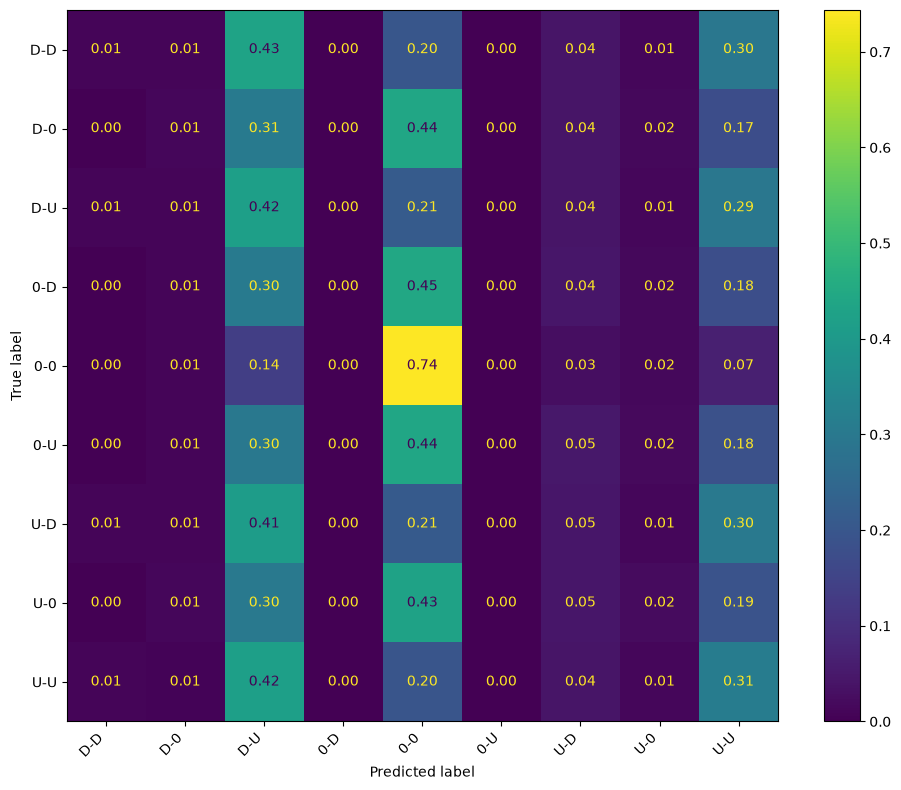

In [18]:
print("Accuracy:", accuracy_score(y_true, pred))
names = ['D-D','D-0','D-U','0-D','0-0','0-U','U-D','U-0','U-U']
print(classification_report(y_true, pred, labels=range(9), target_names=names))

fig, ax = plt.subplots(figsize=(10,8))

ConfusionMatrixDisplay.from_predictions(y_true, pred, labels=range(9), display_labels=names, normalize='true', values_format='.2f', ax=ax)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

<div style="background:blue; color:white; padding:10px; margin-bottom:10px;">

# Detect Overfit
</div>


In [19]:
########################################################
# Check Train Vs Test Overfit
########################################################
train_eval_loader = DataLoader( TensorDataset(X_train_t), batch_size=batchSize )

train_preds = []

with torch.no_grad():
    for (X_batch,) in train_eval_loader:
        out, _ = lstm(X_batch.to(dev))
        train_preds.append(fc(out[:, -1, :]).argmax(1).cpu())

pred_train = torch.cat(train_preds).numpy()
y_train_true = y_train_seq

a = classification_report(y_train_true, pred_train, labels=range(9)).splitlines()
b = classification_report(y_true, pred, labels=range(9)).splitlines()
w = max(map(len, a)) + 4

print(f"{'TRAIN':<{w}}TEST")
print("\n".join(map(lambda p: f"{p[0]:<{w}}{p[1]}", zip(a, b))))


TRAIN                                                    TEST
              precision    recall  f1-score   support                  precision    recall  f1-score   support
                                                         
           0       0.22      0.02      0.04    248625               0       0.21      0.01      0.02    181473
           1       0.13      0.01      0.03    201130               1       0.13      0.01      0.03    120069
           2       0.16      0.37      0.22    262325               2       0.17      0.42      0.24    187429
           3       0.00      0.00      0.00    203516               3       0.00      0.00      0.00    120060
           4       0.24      0.79      0.37    296389               4       0.24      0.74      0.36    148260
           5       0.00      0.00      0.00    203075               5       0.00      0.00      0.00    116457
           6       0.13      0.04      0.06    259932               6       0.15      0.05      0.07   